In [18]:
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import transforms

In [19]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [20]:
train_set=torchvision.datasets.MNIST(root="./MNIST",train=True,download=True,transform=transform)
test_set=torchvision.datasets.MNIST(root="./MNIST",train=False,download=True,transform=transform)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:11<00:00, 895kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 672kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.82MB/s]


In [27]:
from torch.utils.data import DataLoader
import torch.optim as optim
train_loader=DataLoader(train_set,batch_size=64,shuffle=True)
test_loader=DataLoader(test_set,batch_size=64)

In [22]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.features=nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    def forward(self,x):
        x=self.features(x)
        x=self.classifier(x)
        return x

In [23]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN,self).__init__()
        self.rnn=nn.LSTM(
            input_size=28,
            hidden_size=128,
            num_layers=2,
            batch_first=True
        )
        self.fc=nn.Linear(128,10)
    def forward(self,x):
        x=x.squeeze(1)
        output,_=self.rnn(x)
        out=output[:,-1,:]
        out=self.fc(out)
        return out

In [28]:
def train_model(model,train_loader,epochs=5):
    criteria=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(),lr=0.001)
    for epoch in range(epochs):
        model.train()
        running_loss=0
        for images,labels in train_loader:
            optimizer.zero_grad()
            outputs=model(images)
            loss=criteria(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss+=loss.item()
        print(f"Epoch{epoch+1/epochs} & Loss ={running_loss/len(train_loader):.4f}")

In [32]:
import numpy
def evaulate_model(model,test_loder):
    model.eval()
    correct=0
    total=0
    all_preds=[]
    all_labels=[]
    with torch.no_grad():
        for images,labels in test_loader:
            outputs=model(images)
            _,predicted=torch.max(outputs,1)
            total+=labels.size(0)
            correct+=(predicted==labels).sum().item()
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
            accuracy=100*correct/total
            return accuracy,all_labels,all_preds

In [29]:
cnn_model=CNN()
rnn_model=RNN()
train_model(cnn_model,train_loader)
train_model(rnn_model,train_loader)

Epoch0.2 & Loss =0.1563
Epoch1.2 & Loss =0.0461
Epoch2.2 & Loss =0.0325
Epoch3.2 & Loss =0.0234
Epoch4.2 & Loss =0.0182
Epoch0.2 & Loss =0.3757
Epoch1.2 & Loss =0.0890
Epoch2.2 & Loss =0.0589
Epoch3.2 & Loss =0.0492
Epoch4.2 & Loss =0.0391


In [33]:
cnn_acc,cnn_labels,cnn_preds=evaulate_model(cnn_model,test_loader)
rnn_acc,rnn_labels,rnn_preds=evaulate_model(rnn_model,test_loader)
print("CNN Acuracy",cnn_acc)
print("RNN Accuracy",rnn_acc)

CNN Acuracy 100.0
RNN Accuracy 95.3125


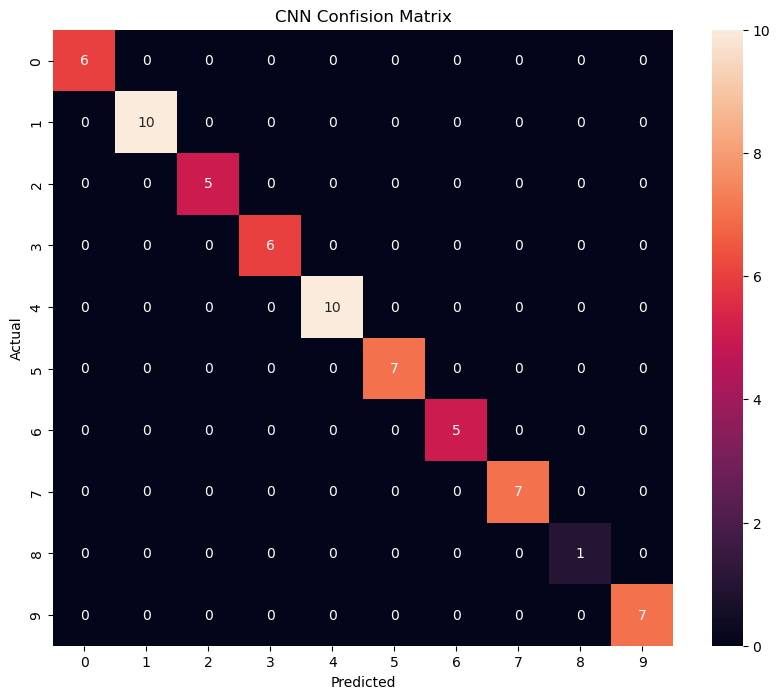

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(cnn_labels,cnn_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confision Matrix")
plt.show()

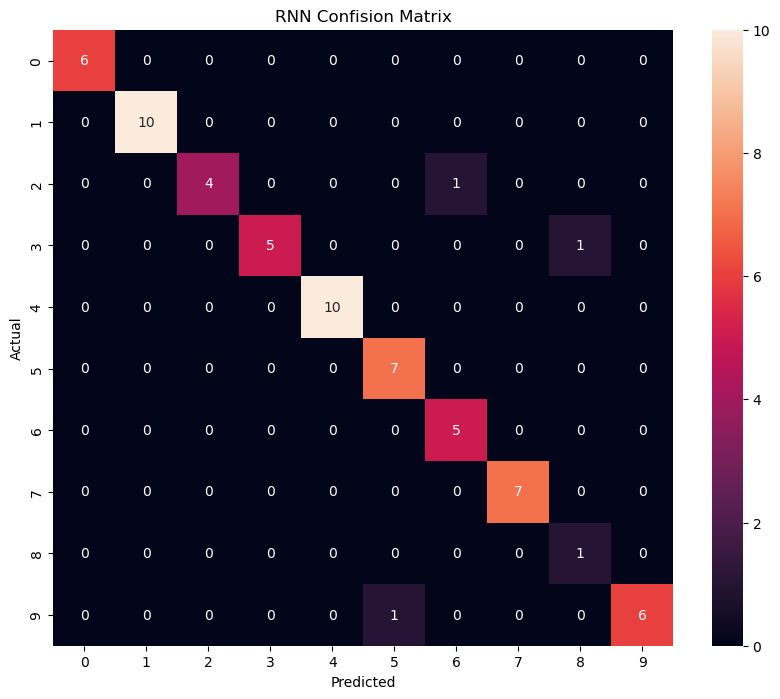

In [36]:
cm=confusion_matrix(rnn_labels,rnn_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RNN Confision Matrix")
plt.show()